In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

/Users/jaspreetkaur/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/8w/70d9nj0n3fg4mz1rrt0dd2780000gn/T/matplotlib-93i72clr because there was an issue with the default path (/Users/jaspreetkaur/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv('Churn_Modelling.csv')

In [4]:
df.head(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0


In [6]:
df = pd.read_csv('Churn_Modelling.csv',usecols=['Age','Balance','Exited'])

In [7]:
df.dropna(inplace=True)

In [8]:
df.shape

(10000, 3)

In [9]:
df.head()

,Age,Balance,Exited
0,42,0.00,1
1,41,83807.86,0
2,42,159660.80,1
3,39,0.00,0
4,43,125510.82,0


In [22]:
X = df.iloc[:, :-1] 
y = df.iloc[:, -1]  

In [23]:
X.head(3)

,Age,Balance
0,42,0.00
1,41,83807.86
2,42,159660.80


In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
clf = DecisionTreeClassifier()

In [26]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [27]:
accuracy_score(y_test,y_pred)

0.7595

In [28]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.7573000000000001)

In [29]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [30]:
kbin_balance = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [31]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_balance,[1])
])

In [32]:
X_train_trf = trf.fit_transform(X_train)

/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/sit

In [33]:
X_test_trf = trf.transform(X_test)

In [34]:
trf.named_transformers_['first'].bin_edges_

array([array([18., 26., 29., 31., 32., 34., 35., 37., 38., 39., 41., 43., 46.,
              50., 57., 92.])                                                 ],
      dtype=object)

In [35]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [36]:
accuracy_score(y_test,y_pred2)

0.8095

In [37]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/sit

np.float64(0.7573)

In [38]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_balance = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_balance,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Balance'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Balance")

    plt.show()

/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/sit

0.7576


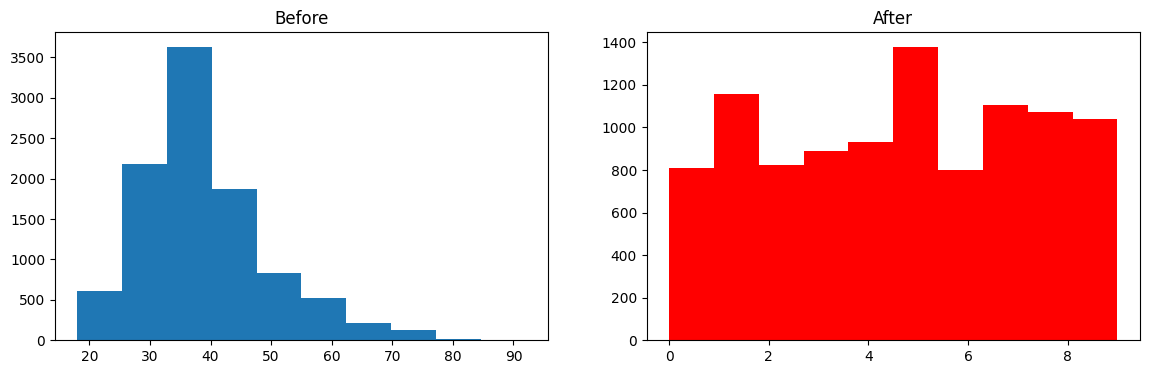

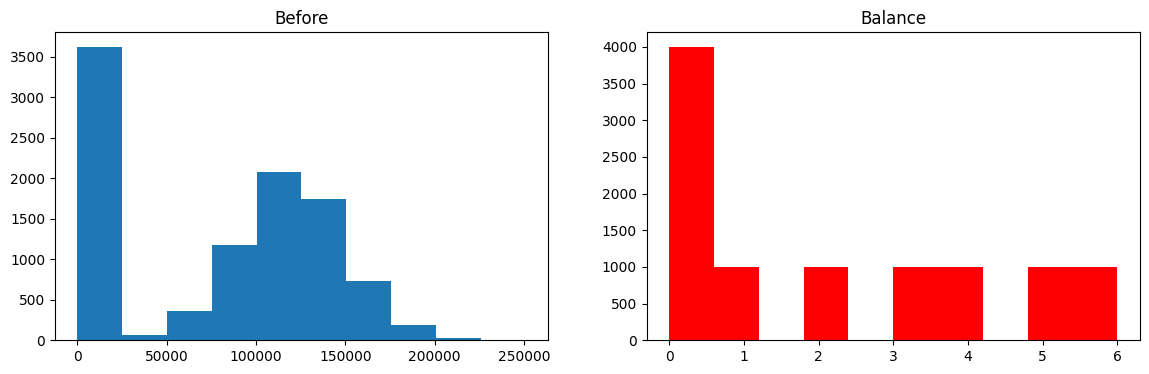

In [39]:
discretize(10,'quantile')

/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/jaspreetkaur/Documents/NN/ML/100 Days of ML/mynewenv/lib/python3.14/sit

0.7569


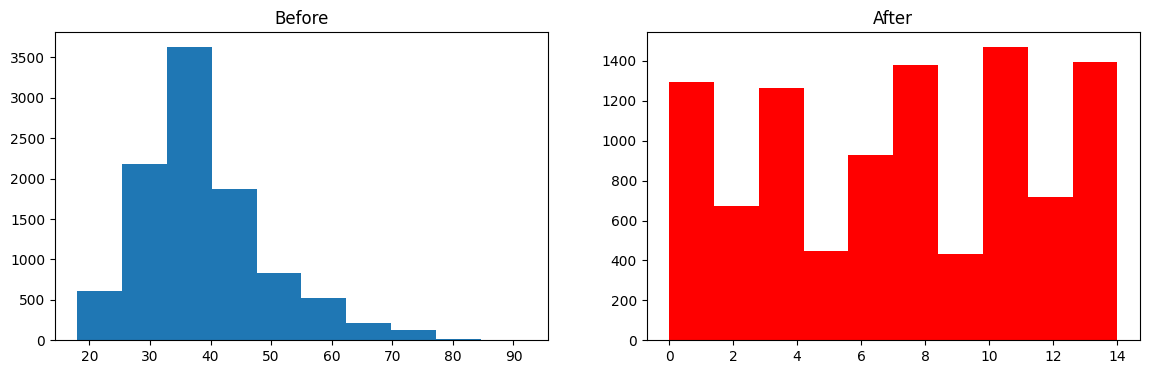

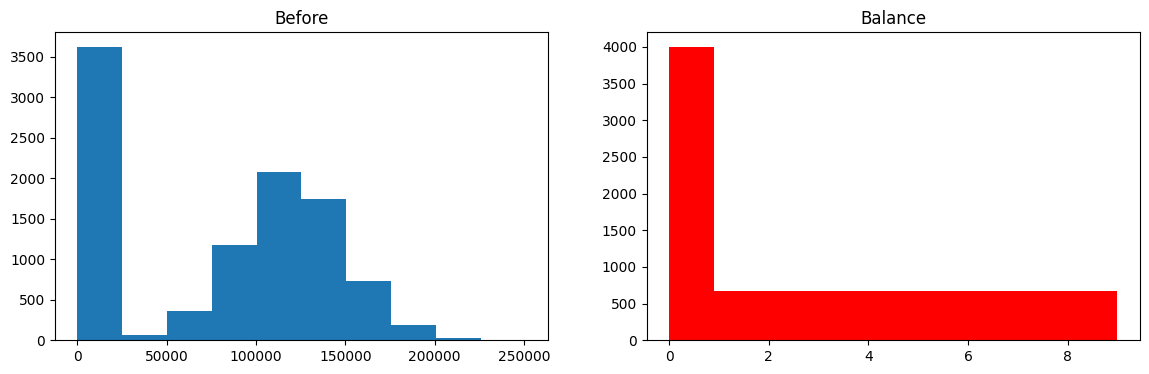

In [40]:
discretize(15,'quantile')

0.7581


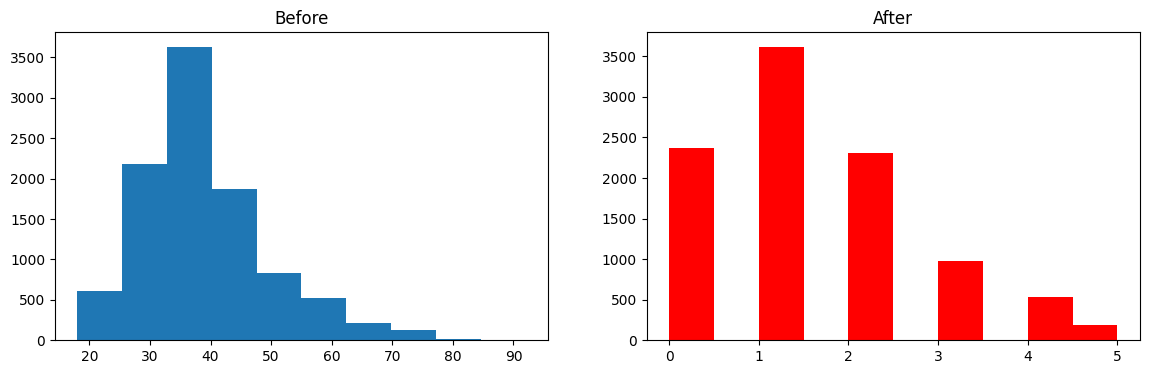

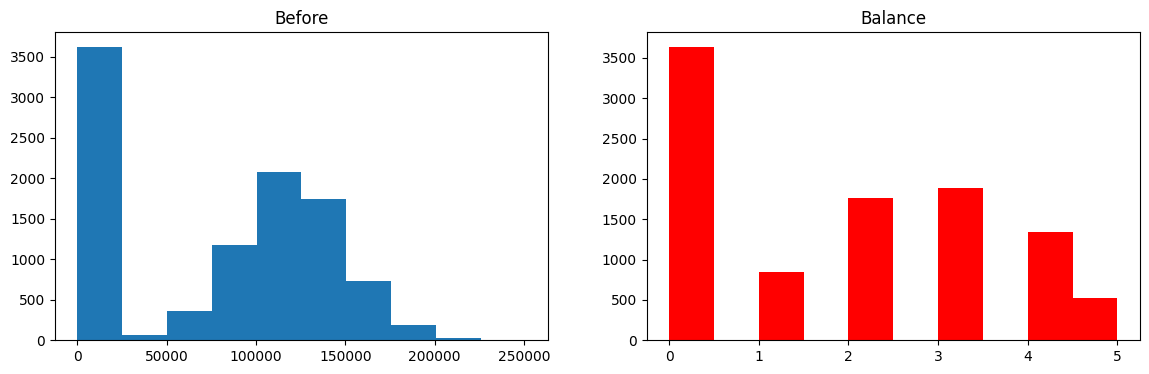

In [41]:
discretize(6,'kmeans')